# TensorFlow

## Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

### Data Generation

In [19]:
obs = 1000

xs = np.random.uniform(-10,10,(obs,1))
zs = np.random.uniform(-10,10,(obs,1))

generated_input = np.column_stack((xs,zs))

noise = np.random.uniform(-1,1,(obs,1))

generated_targets = 2*xs - 3*zs + 5 + noise

#saves multiple numpy arrays in single file
np.savez('TF_intro',inputs=generated_input,targets=generated_targets)

## Using TensorFlow

In [20]:
training_data = np.load('TF_intro.npz')

#sizes
input_s = 2
output_s = 1

## Model

In [21]:

#building model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(output_s) #works as np.dot(input,weights)+bias
])

#model configuration
model.compile(optimizer='sgd',loss='mean_squared_error') # SGD = Stochastic gradient Descent , MSE = l2_norm

#Fitting the data
model.fit(training_data['inputs'],training_data['targets'],epochs=100,verbose=1) #Epoch = Iterations

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 27.5122
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7778
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5787
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6950
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4492
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3840
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3648
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3637
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3634
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3657
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3570
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3581
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3589
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3560
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3590
Ep

In [22]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [23]:
#Weights and Biases
weights = model.layers[0].get_weights()[0]

biases = model.layers[0].get_weights()[1]

In [24]:
weights


array([[ 2.0076644],
       [-2.9961298]], dtype=float32)

In [25]:
biases

array([5.0013847], dtype=float32)

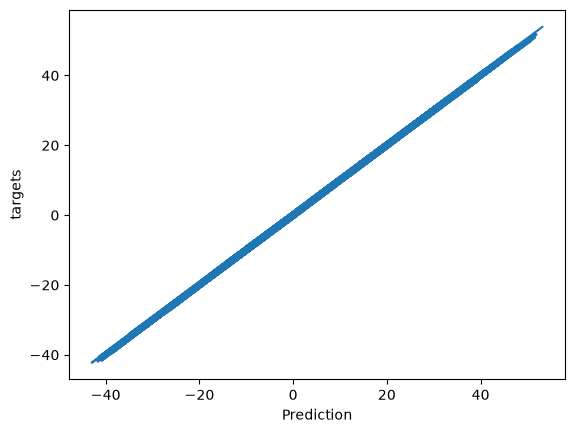

In [27]:
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])),np.squeeze(training_data['targets']))
plt.xlabel('Prediction')
plt.ylabel('targets')
plt.show()
